### Diabetic with Pipeline

In [34]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [35]:

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.impute import KNNImputer

from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)


In [36]:

df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)

y = df["Outcome"]


In [37]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [38]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [39]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)


In [40]:

pipeline = Pipeline([
    
    ("imputer", KNNImputer(n_neighbors=5)),  # handle zeros/missing
    
    ("scaler", StandardScaler()),            # normalize features
    
    ("classifier", GaussianNB())             # model
    
])


In [41]:
pipeline

Pipeline(steps=[('imputer', KNNImputer()), ('scaler', StandardScaler()),
                ('classifier', GaussianNB())])

In [42]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('imputer', KNNImputer()), ('scaler', StandardScaler()),
                ('classifier', GaussianNB())])

In [43]:

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:, 1]


In [44]:
y_pred

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1],
      dtype=int64)

In [45]:
y_prob

array([2.36085297e-02, 1.36634248e-02, 5.96272668e-01, 7.62305737e-01,
       4.59048414e-02, 4.03761355e-02, 4.91753590e-02, 9.74177305e-01,
       2.10061166e-01, 2.96136593e-01, 9.94384372e-01, 3.24410701e-01,
       1.65148454e-01, 6.18516306e-01, 3.28382221e-01, 8.96256078e-01,
       1.04086137e-01, 5.44413513e-02, 1.71194570e-02, 8.94630943e-02,
       2.49500551e-01, 2.88562108e-01, 4.48483569e-01, 1.18462709e-02,
       1.66172320e-02, 1.15435619e-01, 7.88612817e-02, 9.77469232e-01,
       1.79744762e-01, 7.19367811e-01, 4.47853107e-01, 3.93496949e-02,
       2.72398470e-02, 9.66399908e-01, 2.05102469e-01, 6.53615518e-01,
       1.24756662e-02, 5.77722059e-02, 1.14275835e-02, 1.64543689e-02,
       7.58430133e-01, 2.27299612e-01, 7.75985839e-02, 8.98477418e-01,
       1.73172381e-01, 1.24528256e-01, 4.69562639e-01, 6.24549525e-02,
       1.60927067e-02, 7.68480551e-02, 1.35507638e-01, 9.75173091e-02,
       8.87156705e-01, 4.09387914e-02, 8.59277492e-01, 1.53761271e-01,
      

In [46]:

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7727272727272727

Confusion Matrix:
 [[88 12]
 [23 31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       100
           1       0.72      0.57      0.64        54

    accuracy                           0.77       154
   macro avg       0.76      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154



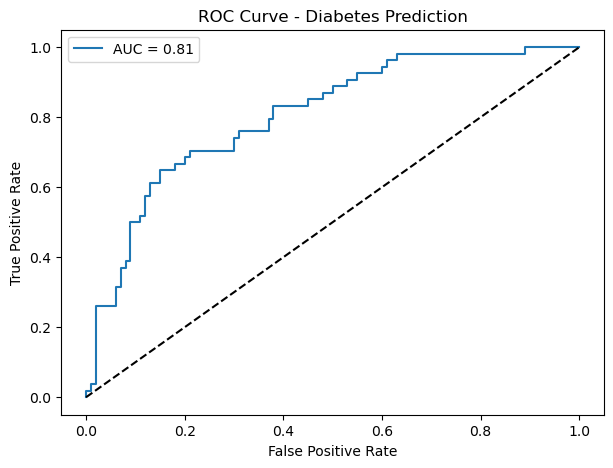

In [47]:

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Diabetes Prediction")
plt.legend()
plt.show()


In [48]:

feature_names = X.columns.tolist()

input_data_df = pd.DataFrame([{
    'Pregnancies': 5,
    'Glucose': 166,
    'BloodPressure': 72,
    'SkinThickness': 19,
    'Insulin': 175,
    'BMI': 25.8,
    'DiabetesPedigreeFunction': 0.587,
    'Age': 51
}])

prediction = pipeline.predict(input_data_df)

probability = pipeline.predict_proba(input_data_df)[0][1] * 100

In [49]:
print("Prediction:", "Diabetic" if prediction[0] == 1 else "Not Diabetic")

print(f"Probability: {probability:.2f}%")

Prediction: Diabetic
Probability: 67.42%


### lifecycle as pipeline

In [50]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest, chi2

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


In [51]:

df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [52]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)


In [53]:

pipeline = Pipeline([
    
    ("imputer", KNNImputer(n_neighbors=5)),
    
    ("selector", SelectKBest(score_func=chi2, k=5)),   
    
    ("scaler", StandardScaler()),
    
    ("classifier", GaussianNB())

])

In [54]:
pipeline

Pipeline(steps=[('imputer', KNNImputer()),
                ('selector',
                 SelectKBest(k=5,
                             score_func=<function chi2 at 0x000002331F087920>)),
                ('scaler', StandardScaler()), ('classifier', GaussianNB())])

In [55]:

pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', KNNImputer()),
                ('selector',
                 SelectKBest(k=5,
                             score_func=<function chi2 at 0x000002331F087920>)),
                ('scaler', StandardScaler()), ('classifier', GaussianNB())])


named_steps is a dictionary

named_steps = a dictionary mapping step-name → object.

named_steps = Dictionary of all steps in the pipeline

✔ named_steps["selector"] = The SelectKBest object

✔ named_steps["model"] = The classifier

✔ named_steps["scaler"] = The StandardScaler


In [56]:

selector = pipeline.named_steps["selector"]

mask = selector.get_support()

selected_features = X.columns[mask]

selected_features

Index(['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'Age'], dtype='object')

In [57]:
for f in selected_features:
    print("✔", f)

✔ Pregnancies
✔ Glucose
✔ Insulin
✔ BMI
✔ Age


In [58]:

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]


In [59]:
y_pred

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1],
      dtype=int64)

In [60]:
y_prob

array([4.38972112e-02, 2.83849609e-02, 7.22110002e-01, 8.23257772e-01,
       7.39933592e-02, 5.09997206e-02, 1.06076066e-01, 9.35366403e-01,
       2.96900569e-01, 4.10825516e-01, 9.86656811e-01, 4.41068355e-01,
       2.52689252e-01, 6.11713926e-01, 3.81951753e-01, 9.36914365e-01,
       9.74300671e-02, 9.27373650e-02, 3.45526900e-02, 1.61420525e-01,
       3.42882255e-01, 1.78759955e-01, 6.26852355e-01, 1.39473610e-02,
       8.75218622e-03, 2.19118059e-01, 1.10394861e-01, 8.89190650e-01,
       2.57758670e-01, 7.35434418e-01, 5.18203591e-01, 7.37229425e-02,
       4.08185449e-02, 9.73896254e-01, 1.93330871e-01, 7.19428797e-01,
       2.55106790e-02, 9.73043380e-02, 2.29506567e-02, 2.82449216e-02,
       8.65754025e-01, 1.53322759e-01, 1.42476731e-01, 8.26733664e-01,
       2.68907227e-01, 2.07683832e-01, 3.57926477e-01, 1.07433926e-01,
       2.43427624e-02, 5.95498280e-02, 1.78061221e-01, 5.43835499e-02,
       8.69007740e-01, 4.78091876e-02, 5.87136872e-01, 1.57668269e-01,
      

In [61]:

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7597402597402597

Confusion Matrix:
 [[88 12]
 [25 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.88      0.83       100
           1       0.71      0.54      0.61        54

    accuracy                           0.76       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.75      0.76      0.75       154



In [62]:

input_data_df = pd.DataFrame(
    [[5,166,72,19,175,25.8,0.587,51]],
    columns=X.columns
)

prediction = pipeline.predict(input_data_df)

probability = pipeline.predict_proba(input_data_df)[0][1] * 100


In [63]:

print("Prediction:", "Diabetic" if prediction[0] == 1 else "Not Diabetic")

print(f"Probability: {probability:.2f}%")


Prediction: Diabetic
Probability: 76.71%
